In [16]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Path to dataset files: /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3


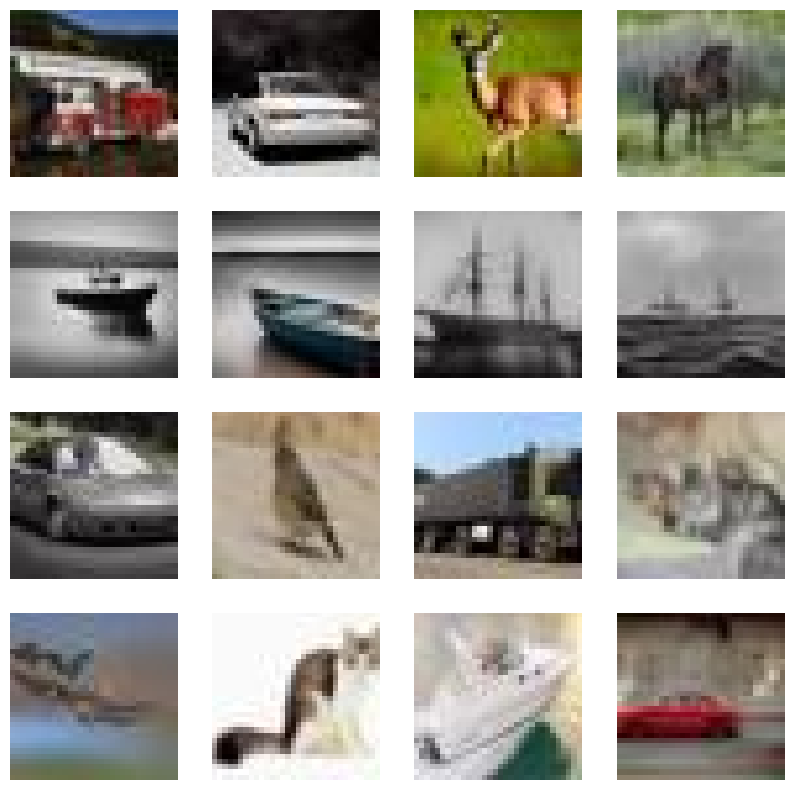

In [18]:
import glob
import random

folder=path+'/'
paths=glob.glob(folder+"*/*/*.jpg")
_, axes = plt.subplots(4, 4, figsize=(10, 10))
random.shuffle(paths)
for ax, img_path in zip(axes.flatten(), paths):
    ax.imshow(Image.open(img_path))
    ax.axis("off")

In [19]:
# Set device (GPU support for Mac M-series or NVIDIA)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
# Configuration
CONFIG = {
    "ROOT_DIR": path,
    "BATCH_SIZE": 32,
    "IMG_SIZE": 224,
    "NUM_WORKERS": 2
}

# Define Transforms (Normalization required for pre-trained models)
data_transforms = {

    'train': transforms.Compose([
        transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])), # 224x224
        transforms.RandomHorizontalFlip(), # Augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        # mean and std of imagenet dataset, to utilize the pre-learned weights of these models
    ]),

    'test': transforms.Compose([
        transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print(f"Configuration: {CONFIG}")

Configuration: {'ROOT_DIR': '/home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3', 'BATCH_SIZE': 32, 'IMG_SIZE': 224, 'NUM_WORKERS': 2}


In [21]:
class CIFAKEDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get Path
        img_name = self.dataframe.iloc[idx, 0]
        img_path = os.path.join(self.root_dir, img_name)

        # 2. Get Label
        label = int(self.dataframe.iloc[idx, 1])

        # Load Image
        image = Image.open(img_path).convert('RGB')

        # try:
        #   image = Image.open(img_path).convert('RGB')
        # except (IOError, FileNotFoundError):
        #     # Fallback for testing without data: generate black image
        #     print(f"Image not found: {img_path}")
        #     # image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [22]:
import glob

# Construct the path to search for JPG files within the dataset root
# The 'path' variable is already defined from a previous cell.
image_files = glob.glob(f"{path}/**/*.jpg", recursive=True)

In [23]:
print("\nFirst 5 image files:")
for file in image_files[:5]:
    print(f"- {file}")

print("\nLast 5 image files:")
for file in image_files[-5:]:
    print(f"- {file}")


First 5 image files:
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/train/REAL/3605 (10).jpg
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/train/REAL/4854 (10).jpg
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/train/REAL/0851 (5).jpg
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/train/REAL/2701 (5).jpg
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/train/REAL/1969 (7).jpg

Last 5 image files:
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/test/FAKE/475 (2).jpg
- /home/sadikshya/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3/test/FAKE/129.jpg
- /home/sadikshya/.cache/

In [24]:
def build_dataframe(root_dir, split):

    data = []
    classes = {'REAL': 0, 'FAKE': 1}

    split_path = os.path.join(root_dir, split) # root/train, root/test

    for class_name, label in classes.items():
        class_path = os.path.join(split_path, class_name)

        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                # train/REAL/img1.jpg
                relative_path = os.path.join(split, class_name, img_name)
                data.append({'filename': relative_path, 'label': label})

    df = pd.DataFrame(data)
    return df.sample(frac=1).reset_index(drop=True) # Shuffle

In [25]:
xyz = build_dataframe(CONFIG['ROOT_DIR'], 'train')
print(xyz)

                       filename  label
0       train/FAKE/2199 (4).jpg      1
1       train/FAKE/1936 (7).jpg      1
2       train/FAKE/4459 (8).jpg      1
3           train/FAKE/2289.jpg      1
4       train/REAL/3856 (3).jpg      0
...                         ...    ...
99995   train/REAL/3682 (8).jpg      0
99996  train/REAL/1783 (10).jpg      0
99997       train/REAL/2899.jpg      0
99998   train/REAL/2378 (5).jpg      0
99999   train/REAL/1850 (2).jpg      0

[100000 rows x 2 columns]


In [26]:
# Load DataFrames
print("Scanning dataset directories...")

train_df = build_dataframe(CONFIG['ROOT_DIR'], 'train')
test_df = build_dataframe(CONFIG['ROOT_DIR'], 'test')

print(f"Training Set: {len(train_df)} images")
print(f"Testing Set: {len(test_df)} images")

# 5. Create Loaders (Uses the CIFAKEDataset class defined in previous steps)
datasets = {
    'train': CIFAKEDataset(train_df, CONFIG['ROOT_DIR'], transform=data_transforms['train']),
    'test': CIFAKEDataset(test_df, CONFIG['ROOT_DIR'], transform=data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(datasets['train'], batch_size=CONFIG['BATCH_SIZE'], shuffle=(True), num_workers=CONFIG['NUM_WORKERS']),
    'test': DataLoader(datasets['test'], batch_size=CONFIG['BATCH_SIZE'], shuffle=(False), num_workers=CONFIG['NUM_WORKERS'])
}

print("Dataloaders ready.")

Scanning dataset directories...
Training Set: 100000 images
Testing Set: 20000 images
Dataloaders ready.


In [27]:
def initialize_model(model_name, num_classes=2, feature_extract=True):
    model = None
    weights = 'DEFAULT' # Use best available pre-trained weights

    print(f"Initializing {model_name}...")

    if model_name == "resnet50":
        model = models.resnet50(weights=weights)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=weights)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    elif model_name == "vit":
        model = models.vit_b_16(weights=weights)
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

In [28]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5):
    since = time.time()

    val_acc_history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'test':
                val_acc_history.append(epoch_acc.cpu().item())

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)

    return model, val_acc_history, time_elapsed

In [29]:
# Define architectures to compare
# models_to_test = ["resnet50", "efficientnet_b0", "vit"]
models_to_test = ["resnet50"]
results = {}

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=15)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing resnet50...

--- Training resnet50 ---
Epoch 1/15
----------
train Loss: 0.1998 Acc: 0.9213
test Loss: 0.1434 Acc: 0.9456
Epoch 2/15
----------
train Loss: 0.1491 Acc: 0.9427
test Loss: 0.1315 Acc: 0.9545
Epoch 3/15
----------
train Loss: 0.1267 Acc: 0.9515
test Loss: 0.1172 Acc: 0.9559
Epoch 4/15
----------
train Loss: 0.1123 Acc: 0.9573
test Loss: 0.0974 Acc: 0.9627
Epoch 5/15
----------
train Loss: 0.0984 Acc: 0.9627
test Loss: 0.0940 Acc: 0.9637
Epoch 6/15
----------
train Loss: 0.0903 Acc: 0.9659
test Loss: 0.0954 Acc: 0.9637
Epoch 7/15
----------
train Loss: 0.0820 Acc: 0.9695
test Loss: 0.0913 Acc: 0.9666
Epoch 8/15
----------
train Loss: 0.0742 Acc: 0.9721
test Loss: 0.0908 Acc: 0.9666
Epoch 9/15
----------
train Loss: 0.0688 Acc: 0.9742
test Loss: 0.0819 Acc: 0.9686
Epoch 10/15
----------
train Loss: 0.0616 Acc: 0.9760
test Loss: 0.0749 Acc: 0.9711
Epoch 11/15
----------
train Loss: 0.0563 Acc: 0.9784
test Loss: 0.0743 Acc: 0.9728
Epoch 12/15
----------
train Loss

In [30]:
# Define architectures to compare
models_to_test = ["efficientnet_b0"]

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=15)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing efficientnet_b0...

--- Training efficientnet_b0 ---
Epoch 1/15
----------
train Loss: 0.1481 Acc: 0.9424
test Loss: 0.0889 Acc: 0.9672
Epoch 2/15
----------
train Loss: 0.0998 Acc: 0.9628
test Loss: 0.0918 Acc: 0.9663
Epoch 3/15
----------
train Loss: 0.0831 Acc: 0.9695
test Loss: 0.0876 Acc: 0.9692
Epoch 4/15
----------
train Loss: 0.0700 Acc: 0.9740
test Loss: 0.0605 Acc: 0.9777
Epoch 5/15
----------
train Loss: 0.0616 Acc: 0.9769
test Loss: 0.0548 Acc: 0.9799
Epoch 6/15
----------
train Loss: 0.0542 Acc: 0.9798
test Loss: 0.0571 Acc: 0.9803
Epoch 7/15
----------
train Loss: 0.0483 Acc: 0.9822
test Loss: 0.0829 Acc: 0.9772
Epoch 8/15
----------
train Loss: 0.0443 Acc: 0.9832
test Loss: 0.0474 Acc: 0.9828
Epoch 9/15
----------
train Loss: 0.0387 Acc: 0.9856
test Loss: 0.0468 Acc: 0.9830
Epoch 10/15
----------
train Loss: 0.0363 Acc: 0.9867
test Loss: 0.0733 Acc: 0.9763
Epoch 11/15
----------
train Loss: 0.0336 Acc: 0.9876
test Loss: 0.0659 Acc: 0.9806
Epoch 12/15
-------

In [31]:
# Define architectures to compare
models_to_test = ["vit"]

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=15)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing vit...

--- Training vit ---
Epoch 1/15
----------
train Loss: 0.5595 Acc: 0.6878
test Loss: 0.4032 Acc: 0.8155
Epoch 2/15
----------
train Loss: 0.3367 Acc: 0.8529
test Loss: 0.2983 Acc: 0.8704
Epoch 3/15
----------
train Loss: 0.2745 Acc: 0.8840
test Loss: 0.2458 Acc: 0.8985
Epoch 4/15
----------
train Loss: 0.2425 Acc: 0.8995
test Loss: 0.2394 Acc: 0.9020
Epoch 5/15
----------
train Loss: 0.2193 Acc: 0.9110
test Loss: 0.2217 Acc: 0.9133
Epoch 6/15
----------
train Loss: 0.2029 Acc: 0.9180
test Loss: 0.1873 Acc: 0.9250
Epoch 7/15
----------
train Loss: 0.1912 Acc: 0.9229
test Loss: 0.1786 Acc: 0.9291
Epoch 8/15
----------
train Loss: 0.1804 Acc: 0.9289
test Loss: 0.1752 Acc: 0.9306
Epoch 9/15
----------
train Loss: 0.1704 Acc: 0.9332
test Loss: 0.1635 Acc: 0.9381
Epoch 10/15
----------
train Loss: 0.1637 Acc: 0.9350
test Loss: 0.1630 Acc: 0.9375
Epoch 11/15
----------
train Loss: 0.1564 Acc: 0.9374
test Loss: 0.1885 Acc: 0.9260
Epoch 12/15
----------
train Loss: 0.1518 A

In [32]:
# Save all trained models
import os

# Create models1 directory
os.makedirs("models1", exist_ok=True)

# Save all models from results dictionary
print("Saving trained models...")
for model_name, data in results.items():
    model_save_path = f"models1/{model_name}_best.pth"
    torch.save(data['model'].state_dict(), model_save_path)
    print(f"Saved {model_name} to {model_save_path}")

Saving trained models...
Saved resnet50 to models1/resnet50_best.pth
Saved efficientnet_b0 to models1/efficientnet_b0_best.pth
Saved vit to models1/vit_best.pth


🔍 Visualizing misclassified images for efficientnet_b0...


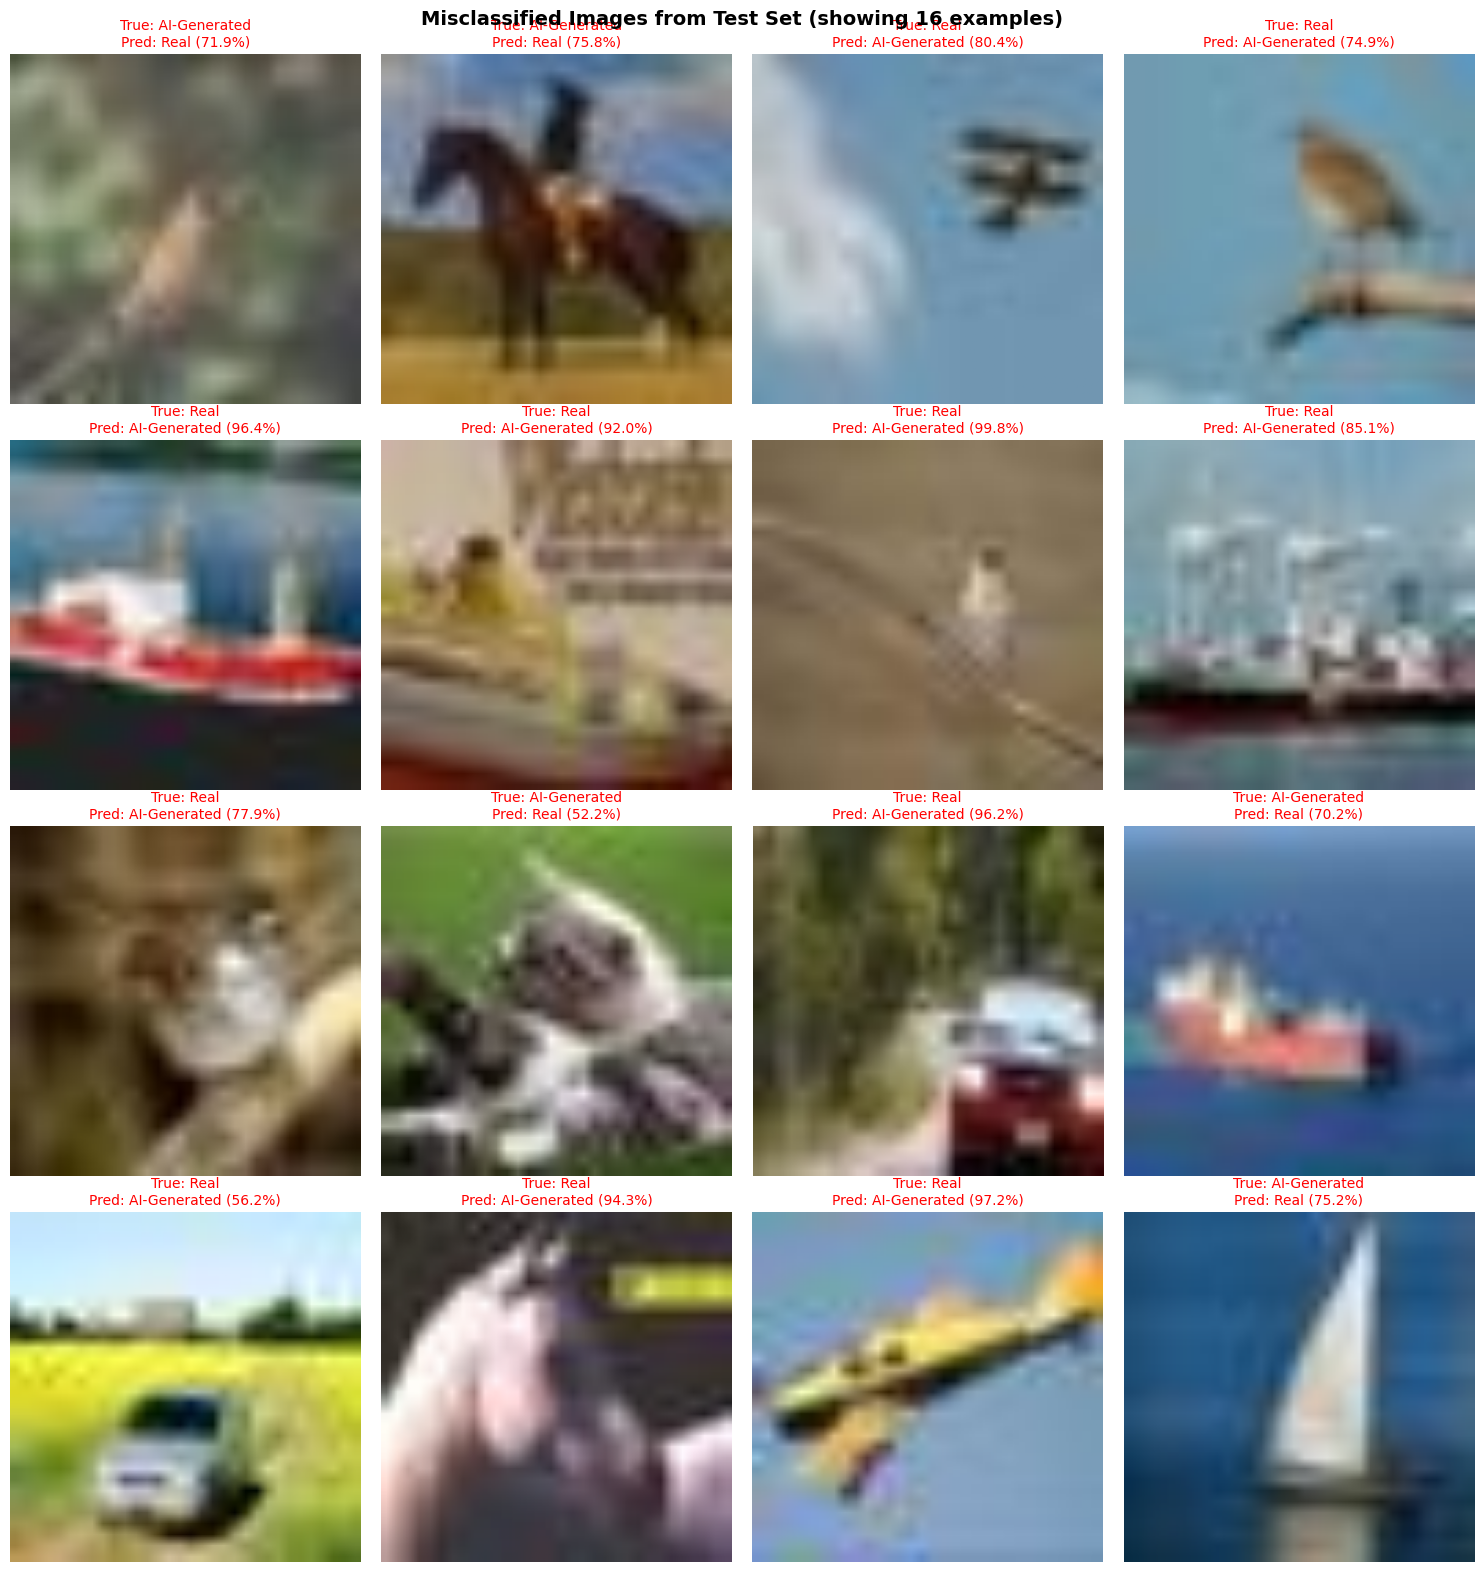


 Found 16 misclassified images (showing up to 16)


In [33]:
def visualize_misclassified_images(model, dataloader, num_images=16):
    model.eval()
    
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []
    misclassified_probs = []
    
    # Collect misclassified images
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs_gpu = inputs.to(device)
            outputs = model(inputs_gpu)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            # Find misclassified
            incorrect = (preds.cpu() != labels)
            if incorrect.any():
                for i in range(len(labels)):
                    if incorrect[i]:
                        # Convert tensor back to image for display
                        img = inputs[i].cpu()
                        # Denormalize for display
                        mean = torch.tensor([0.485, 0.456, 0.406])
                        std = torch.tensor([0.229, 0.224, 0.225])
                        img = img * std[:, None, None] + mean[:, None, None]
                        img = torch.clamp(img, 0, 1)
                        
                        misclassified_images.append(img)
                        misclassified_labels.append(labels[i].item())
                        misclassified_preds.append(preds[i].cpu().item())
                        misclassified_probs.append(probs[i].cpu().numpy())
                        
                        if len(misclassified_images) >= num_images:
                            break
                if len(misclassified_images) >= num_images:
                    break
    
    if len(misclassified_images) == 0:
        print("No misclassified images found! Perfect model!")
        return
    
    # Display misclassified images
    n_cols = 4
    n_rows = (len(misclassified_images) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    class_names = ['Real', 'AI-Generated']
    
    for idx, (img, true_label, pred_label, prob) in enumerate(zip(
        misclassified_images, misclassified_labels, 
        misclassified_preds, misclassified_probs
    )):
        ax = axes[idx]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f"True: {class_names[true_label]}\n"
                    f"Pred: {class_names[pred_label]} "
                    f"({prob[pred_label]*100:.1f}%)",
                    fontsize=10, color='red')
        ax.axis('off')
    
    # Hide extra subplots
    for idx in range(len(misclassified_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified Images from Test Set (showing {len(misclassified_images)} examples)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n Found {len(misclassified_images)} misclassified images (showing up to {num_images})")

# Visualize misclassified images from test set
if 'results' in globals() and len(results) > 0:
    best_model_name = 'efficientnet_b0' if 'efficientnet_b0' in results else list(results.keys())[0]
    print(f"🔍 Visualizing misclassified images for {best_model_name}...")
    visualize_misclassified_images(
        results[best_model_name]['model'],
        dataloaders['test'],
        num_images=16
    )
else:
    print("No trained models found. Please train models first.")


In [34]:
# Load a saved model and test it
# Use this cell when you want to load a previously saved model

def load_saved_model(model_name):
    
    model_path = f"models1/{model_name}_best.pth"
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}. Please train and save the model first.")
    
    # Initialize model architecture
    model = initialize_model(model_name)
    
    # Load saved weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    print(f"Loaded {model_name} from {model_path}")
    return model

# Example: Load and test a saved model
# Uncomment the lines below to use:

# loaded_model = load_saved_model("efficientnet_b0")
# 
# # Test the loaded model on test dataset
# test_results = comprehensive_test_evaluation(
#     loaded_model,
#     dataloaders['test'],
#     model_name="EfficientNet-B0 (Loaded)"
# )
#
# # Visualize misclassified images
# visualize_misclassified_images(loaded_model, dataloaders['test'], num_images=16)


--- Final Comparative Benchmarks ---


,Accuracy,Precision,Recall,F1 Score
resnet50,0.97275,0.971948,0.9736,0.972773
efficientnet_b0,0.98295,0.980691,0.9853,0.982990
vit,0.94465,0.938468,0.9517,0.945037


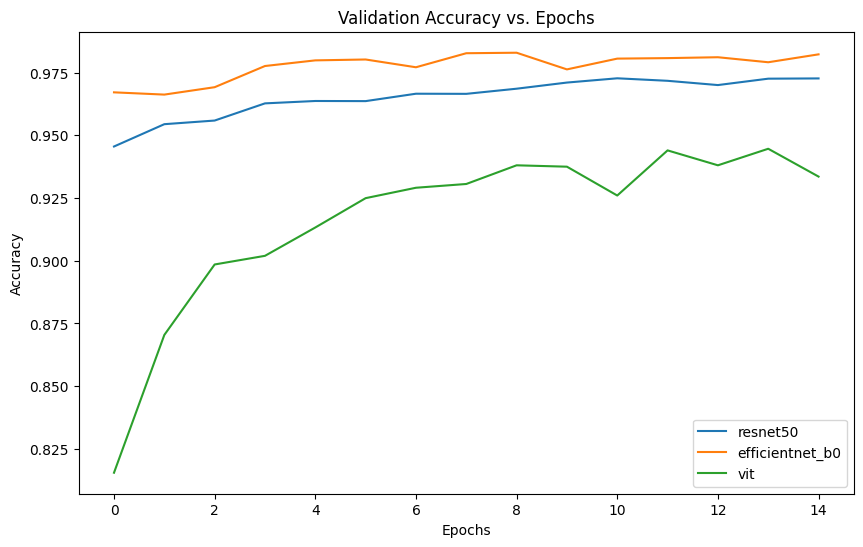

In [35]:
def evaluate_metrics(model, dataloader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    # Inference Loop
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Compute Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='binary')
    rec = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    return [acc, prec, rec, f1]

# Compare all models
metrics_df = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1 Score"])

for name, data in results.items():
    metrics = evaluate_metrics(data['model'], dataloaders['test'], name)
    metrics_df.loc[name] = metrics

print("\n--- Final Comparative Benchmarks ---")
display(metrics_df)

# Plot Training Comparison
plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data['history'], label=name)
plt.title("Validation Accuracy vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [36]:
def predict_image(model, image_path):
    model.eval()
    # Transform image
    img = Image.open(image_path).convert('RGB')
    img_t = data_transforms['test'](img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        _, predicted_class = torch.max(outputs, 1)

    class_names = ['Real', 'AI-Generated']
    confidence = probabilities[predicted_class].item()

    print(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}% confidence)")
    # plt.imshow(img)
    # plt.show()

# Example Usage (Change path to a real image)
predict_image(results['efficientnet_b0']['model'], "image.png")

Prediction: AI-Generated (100.00% confidence)


Loading model: efficientnet_b0...
Initializing efficientnet_b0...
Model loaded successfully!

Image: image.png
Prediction: AI-Generated
Confidence: 100.00%

 Class Probabilities:
  Real           :   0.00% 
  AI-Generated   : 100.00% █████████████████████████████████



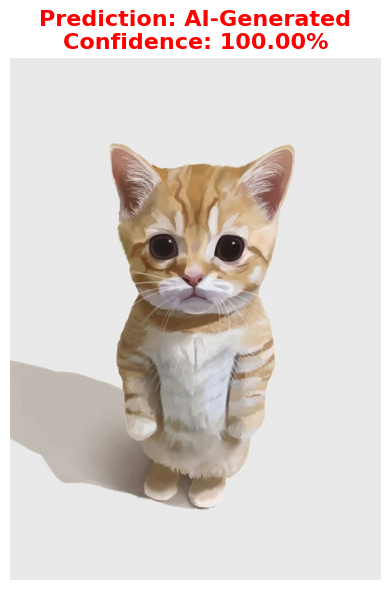

('AI-Generated', 100.0)

In [37]:

def predict_with_saved_model(model_name, image_path, show_image=True):
    # Load the saved model
    model_path = f"models1/{model_name}_best.pth"
    
    if not os.path.exists(model_path):
        print(f" Model not found: {model_path}")
        return None, None
    
    print(f"Loading model: {model_name}...")
    model = initialize_model(model_name)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Model loaded successfully!\n")
    
    # Load and preprocess image
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return None, None
    
    img_t = data_transforms['test'](img).unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(img_t)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        _, predicted_class = torch.max(outputs, 1)

    class_names = ['Real', 'AI-Generated']
    prediction = class_names[predicted_class.item()]
    confidence = probabilities[predicted_class].item() * 100

    # Display results
    print(f"{'='*60}")
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"{'='*60}")
    print(f"\n Class Probabilities:")
    for i, class_name in enumerate(class_names):
        prob = probabilities[i].item() * 100
        bar = "█" * int(prob / 3)  # Visual bar
        print(f"  {class_name:15s}: {prob:6.2f}% {bar}")
    print(f"{'='*60}\n")
    
    # Show image if requested
    if show_image:
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2f}%", 
                  fontsize=16, fontweight='bold', 
                  color='green' if prediction == 'Real' else 'red')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return prediction, confidence


# ============================================================================
# USAGE EXAMPLES - Uncomment and modify the path:
# ============================================================================

# Example 1: Predict with EfficientNet (recommended - best accuracy)
predict_with_saved_model("efficientnet_b0", "image.png")

# Example 2: Predict with ResNet50
# predict_with_saved_model("resnet50", "path/to/your/image.jpg")

# Example 3: Predict without showing image (faster)
# prediction, confidence = predict_with_saved_model("efficientnet_b0", "image.jpg", show_image=False)
# print(f"Result: {prediction} ({confidence:.2f}% confidence)")

# Example 4: Predict multiple images
# image_paths = ["image1.jpg", "image2.jpg", "image3.jpg"]
# for img_path in image_paths:
#     predict_with_saved_model("efficientnet_b0", img_path)